# Squared Loss (Mean Squared Error)

Loss function that measures the squared difference between predicted and true values.

**Single sample:** $L = (y_{true} - y_{pred})^2$

**Mean Squared Error (MSE):** $\displaystyle MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i^{true} - y_i^{pred})^2$

**Gradient:** $\displaystyle\frac{\partial L}{\partial y_{pred}} = -2(y_{true} - y_{pred})$

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def squared_loss(y_true, y_pred):
    """Per-sample squared loss: (y_true - y_pred)^2"""
    return (np.asarray(y_true) - np.asarray(y_pred)) ** 2

print("Setup complete!")

Setup complete!


## Section 1: Single Prediction

In [7]:
y_true = 5.0
y_pred = 3.0
loss = squared_loss(y_true, y_pred)

print(f"y_true = {y_true}, y_pred = {y_pred}")
print(f"Error  = {y_true - y_pred}")
print(f"Loss   = ({y_true} - {y_pred})² = {loss}")

y_true = 5.0, y_pred = 3.0
Error  = 2.0
Loss   = (5.0 - 3.0)² = 4.0


## Section 2: Mean Squared Error (Multiple Predictions)

In [8]:
y_true = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred = np.array([1.1, 1.9, 3.2, 3.8, 5.3])

losses = squared_loss(y_true, y_pred)
mse = np.mean(losses)
rmse = np.sqrt(mse)

print(f"{'Sample':<8} {'y_true':>7} {'y_pred':>7} {'Error':>7} {'Loss':>8}")
print("-" * 40)
for i in range(len(y_true)):
    err = y_true[i] - y_pred[i]
    print(f"{i+1:<8} {y_true[i]:>7.1f} {y_pred[i]:>7.1f} {err:>7.1f} {losses[i]:>8.4f}")
print("-" * 40)
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} (in same units as y)")

Sample    y_true  y_pred   Error     Loss
----------------------------------------
1            1.0     1.1    -0.1   0.0100
2            2.0     1.9     0.1   0.0100
3            3.0     3.2    -0.2   0.0400
4            4.0     3.8     0.2   0.0400
5            5.0     5.3    -0.3   0.0900
----------------------------------------
MSE  = 0.0380
RMSE = 0.1949 (in same units as y)


## Section 3: Visualizing Squared Loss

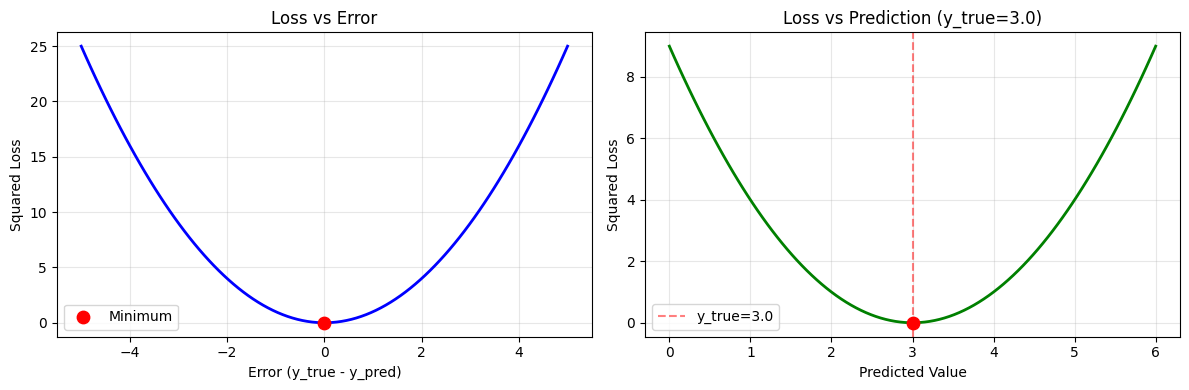

In [9]:
error = np.linspace(-5, 5, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss vs error
ax1.plot(error, error**2, 'b-', linewidth=2)
ax1.scatter([0], [0], color='red', s=80, zorder=5, label='Minimum')
ax1.set_xlabel('Error (y_true - y_pred)')
ax1.set_ylabel('Squared Loss')
ax1.set_title('Loss vs Error')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss vs predicted value (for fixed y_true=3)
y_true_pt = 3.0
y_pred_range = np.linspace(0, 6, 100)
ax2.plot(y_pred_range, (y_true_pt - y_pred_range)**2, 'g-', linewidth=2)
ax2.axvline(x=y_true_pt, color='red', linestyle='--', alpha=0.5, label=f'y_true={y_true_pt}')
ax2.scatter([y_true_pt], [0], color='red', s=80, zorder=5)
ax2.set_xlabel('Predicted Value')
ax2.set_ylabel('Squared Loss')
ax2.set_title(f'Loss vs Prediction (y_true={y_true_pt})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Gradient of Squared Loss

$$\frac{\partial L}{\partial y_{pred}} = -2(y_{true} - y_{pred})$$

The gradient tells us which direction to adjust our prediction to reduce loss.

y_true=5.0, y_pred=3.0
Gradient = -2 * (5.0 - 3.0) = -4.0
Negative gradient means: increase y_pred to reduce loss


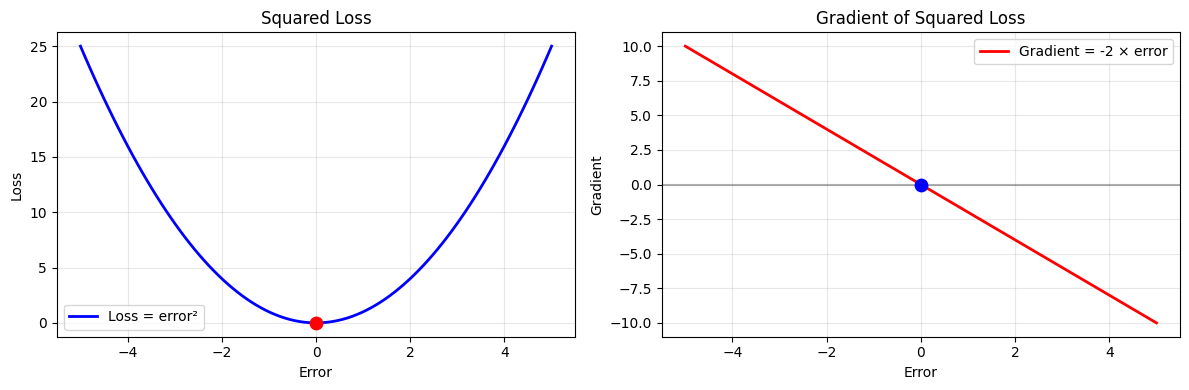


Gradient is zero at error=0 (minimum)
Gradient is linear — larger errors get larger updates


In [10]:
# Numerical example
y_true_val, y_pred_val = 5.0, 3.0
grad = -2 * (y_true_val - y_pred_val)
print(f"y_true={y_true_val}, y_pred={y_pred_val}")
print(f"Gradient = -2 * ({y_true_val} - {y_pred_val}) = {grad}")
print(f"Negative gradient means: increase y_pred to reduce loss")

# Visualize loss and gradient together
error = np.linspace(-5, 5, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(error, error**2, 'b-', linewidth=2, label='Loss = error²')
ax1.scatter([0], [0], color='red', s=80, zorder=5)
ax1.set_xlabel('Error')
ax1.set_ylabel('Loss')
ax1.set_title('Squared Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gradient curve
ax2.plot(error, -2 * error, 'r-', linewidth=2, label='Gradient = -2 × error')
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.scatter([0], [0], color='blue', s=80, zorder=5)
ax2.set_xlabel('Error')
ax2.set_ylabel('Gradient')
ax2.set_title('Gradient of Squared Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Gradient is zero at error=0 (minimum)")
print("Gradient is linear — larger errors get larger updates")

## Summary

**Key properties:**
- Always ≥ 0, equals 0 only for perfect predictions
- Convex — gradient descent finds the global minimum
- Penalizes large errors quadratically (outlier sensitive)
- Gradient is linear in the error → smooth optimization

**Use when:** regression problems with roughly normal errors

**Don't use when:** data has many outliers → use MAE or Huber loss instead